In [102]:
import pandas as pd 
import numpy
from matplotlib import pyplot
import matplotlib.pyplot as plt
from pandas import set_option #to restrict the number of decimals 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

diabetes = pd.read_csv('diabetes.csv')
diabetes.drop_duplicates()
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [103]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [104]:
diabetes.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [105]:
diabetes.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

<AxesSubplot:xlabel='Age', ylabel='Pregnancies'>

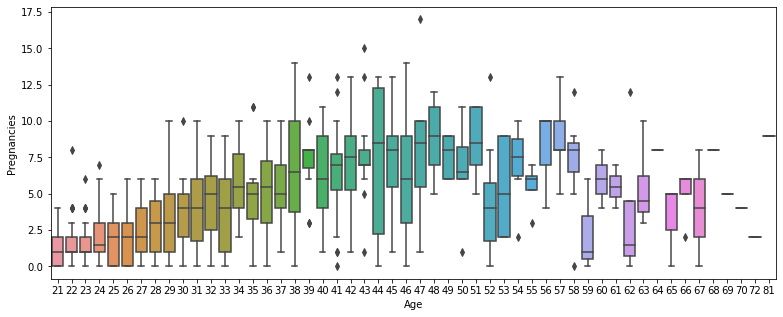

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(13,5))
sns.boxplot(x='Age', y ='Pregnancies', data =diabetes)


<AxesSubplot:xlabel='Age', ylabel='BloodPressure'>

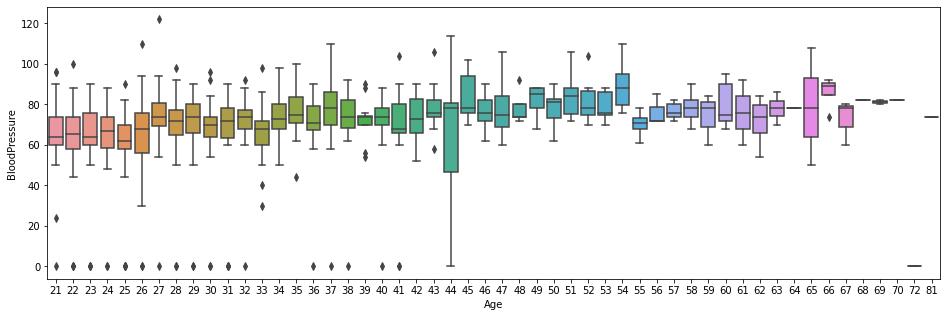

In [107]:
plt.figure(figsize=(16,5))
sns.boxplot(x='Age', y ='BloodPressure', data =diabetes)

<AxesSubplot:xlabel='Age', ylabel='BMI'>

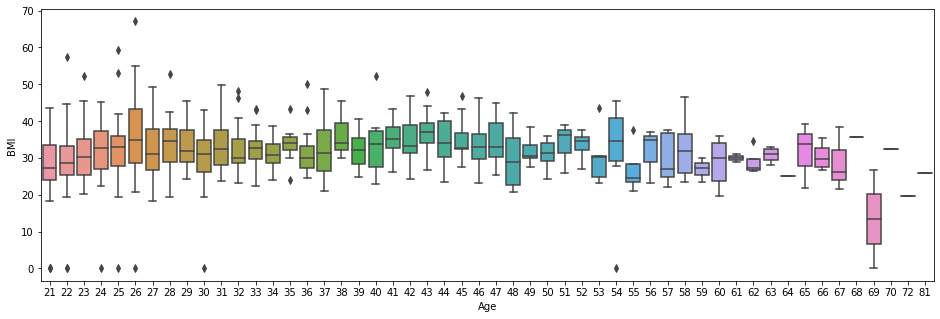

In [108]:
plt.figure(figsize=(16,5))
sns.boxplot(x='Age', y ='BMI', data =diabetes)

array([[<AxesSubplot:title={'center':'Pregnancies'}>,
        <AxesSubplot:title={'center':'Glucose'}>,
        <AxesSubplot:title={'center':'BloodPressure'}>],
       [<AxesSubplot:title={'center':'SkinThickness'}>,
        <AxesSubplot:title={'center':'Insulin'}>,
        <AxesSubplot:title={'center':'BMI'}>],
       [<AxesSubplot:title={'center':'DiabetesPedigreeFunction'}>,
        <AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Outcome'}>]], dtype=object)

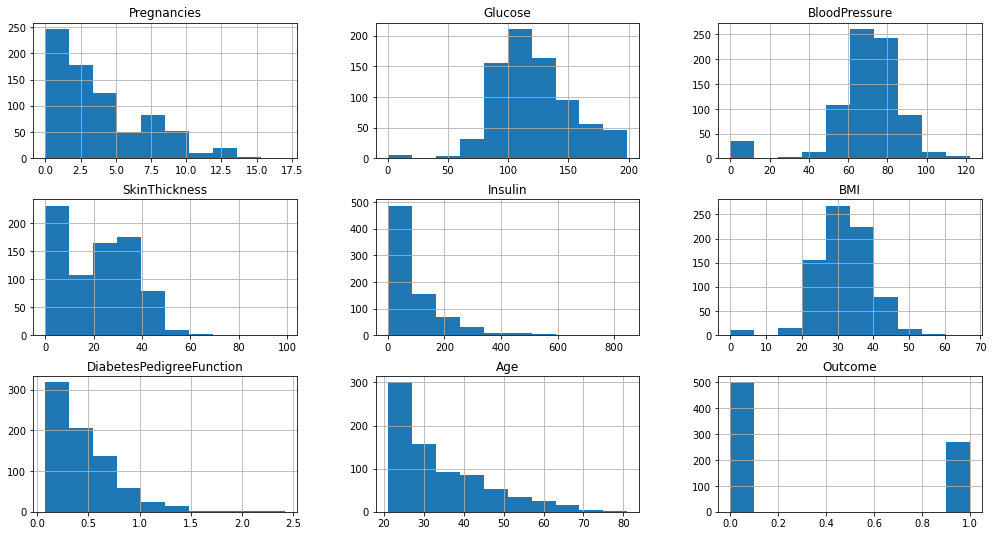

In [109]:
diabetes.hist(figsize=(17,9))

In [110]:
len(diabetes.columns)

9

In [111]:
array = diabetes.values
X = array[:,0:8]
Y = array[:,-1]

f_train, f_test, v_train, v_test = train_test_split(X,Y, test_size=0.3, random_state=42)

In [112]:
num_fold = 10
seed = 7
scoring = 'accuracy'

#for every dataset pick the best models. 
model = []
model.append(('Log Reg', LogisticRegression()))
model.append(('KNN', KNeighborsClassifier()))
model.append(('CART', DecisionTreeClassifier()))
model.append(("NB", GaussianNB()))
model.append(('SVM', SVC()))

results = []
names = []

for name, model in model:
    kfold = KFold(n_splits= num_fold, random_state=None)
    cv_results = cross_val_score(model, f_train, v_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)

/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mo

Log Reg: 0.776485 (0.056354)
KNN: 0.722572 (0.050585)
CART: 0.724144 (0.070038)
NB: 0.754018 (0.063318)
SVM: 0.755940 (0.053992)


Look for model with least amount of variance. 

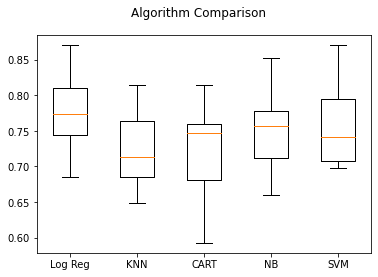

In [113]:
fig = pyplot.figure()
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

Lets use a Pipeline and Standardize the data and tehn build the models. 

In [114]:
from xgboost import XGBClassifier

pipelines = []
pipelines.append(("Scaled Log Reg", Pipeline([('Scaler', StandardScaler()), ('Log Reg', LogisticRegression())])))
pipelines.append(('Scaled KNN', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsClassifier())])))
pipelines.append(('Scaled CART', Pipeline([('Scaler', StandardScaler()), ('CART', DecisionTreeClassifier())])))
pipelines.append(('Scaled NB', Pipeline([('Scaler', StandardScaler()), ('NB', GaussianNB())])))
pipelines.append(('Scaled SVM', Pipeline([('Scaler', StandardScaler()), ('SVM', SVC())])))
pipelines.append(('Scaled XGBM', Pipeline([('Scaler', StandardScaler()), ('XGBM', XGBClassifier())])))


#XGBClassifier(max_depth = 3,use_label_encoder=False)

results = []
names = []

for name, model in pipelines:
    kfold = KFold(n_splits=10, random_state=None)
    cv_results = cross_val_score(model, f_train, v_train, cv=kfold, scoring= scoring)
    results.append(cv_results)
    names.append(name)
    msg = '%s: %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)

Scaled Log Reg: 0.780189 (0.062658)
Scaled KNN: 0.746611 (0.039904)
Scaled CART: 0.720475 (0.074282)
Scaled NB: 0.754018 (0.063318)
Scaled SVM: 0.763522 (0.056717)
[15:56:16] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-p

[15:56:16] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[15:56:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[15:56:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-p

[15:56:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[15:56:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[15:56:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[15:56:17] WARNING: /Users/runner/miniforge3/cond

/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-p

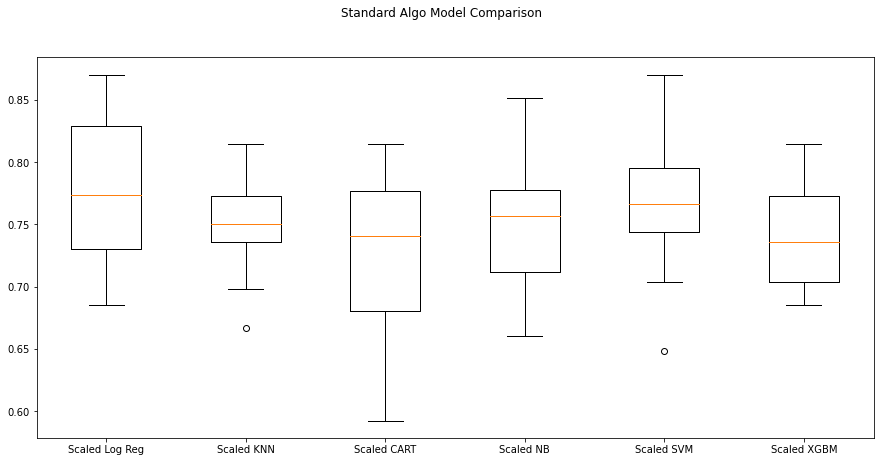

In [115]:
fig = pyplot.figure(figsize=(15,7))
fig.suptitle('Standard Algo Model Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

Going with the Log Reg model. To build the model on the entire dataset. 

In [116]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X,Y)

print(log.coef_)

[[ 1.17252319e-01  3.35995941e-02 -1.40874413e-02 -1.27056220e-03
  -1.24030766e-03  7.72026108e-02  1.41904089e+00  1.00355909e-02]]


/Users/navnoorsingh/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [117]:
print(log.predict_log_proba(X))
print(log.predict_proba(X))

[[-1.24124039 -0.3411187 ]
 [-0.0571416  -2.89065769]
 [-1.74727218 -0.19146154]
 ...
 [-0.1903733  -1.75244543]
 [-0.33924449 -1.24586577]
 [-0.08185411 -2.54346462]]
[[0.28902549 0.71097451]
 [0.94446033 0.05553967]
 [0.17424861 0.82575139]
 ...
 [0.82665049 0.17334951]
 [0.71230827 0.28769173]
 [0.92140637 0.07859363]]


In [118]:
y_pred = log.predict(X)

diabetes['Predicted Diabetes'] = y_pred

diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Predicted Diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.0
1,1,85,66,29,0,26.6,0.351,31,0,0.0
2,8,183,64,0,0,23.3,0.672,32,1,1.0
3,1,89,66,23,94,28.1,0.167,21,0,0.0
4,0,137,40,35,168,43.1,2.288,33,1,1.0
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0.0
764,2,122,70,27,0,36.8,0.340,27,0,0.0
765,5,121,72,23,112,26.2,0.245,30,0,0.0
766,1,126,60,0,0,30.1,0.349,47,1,0.0


In [119]:
y_prob = pd.DataFrame(log.predict_proba(X[:,:]))

new_diabetes = pd.concat([diabetes, y_prob], axis = 1)
new_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Predicted Diabetes,0,1
0,6,148,72,35,0,33.6,0.627,50,1,1.0,0.289025,0.710975
1,1,85,66,29,0,26.6,0.351,31,0,0.0,0.944460,0.055540
2,8,183,64,0,0,23.3,0.672,32,1,1.0,0.174249,0.825751
3,1,89,66,23,94,28.1,0.167,21,0,0.0,0.954944,0.045056
4,0,137,40,35,168,43.1,2.288,33,1,1.0,0.047912,0.952088
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0.0,0.745894,0.254106
764,2,122,70,27,0,36.8,0.340,27,0,0.0,0.688941,0.311059
765,5,121,72,23,112,26.2,0.245,30,0,0.0,0.826650,0.173350
766,1,126,60,0,0,30.1,0.349,47,1,0.0,0.712308,0.287692


In [120]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(Y, y_pred)

print(confusion_matrix)

print(pd.crosstab(Y, y_pred))


[[447  53]
 [114 154]]
col_0  0.0  1.0
row_0          
0.0    447   53
1.0    114  154


In [121]:
from sklearn.metrics import classification_report

print(classification_report(Y, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84       500
         1.0       0.74      0.57      0.65       268

    accuracy                           0.78       768
   macro avg       0.77      0.73      0.75       768
weighted avg       0.78      0.78      0.77       768



In [122]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

roc_diab = roc_auc_score(Y, log.predict(X))

print(roc_diab)

0.7343134328358208


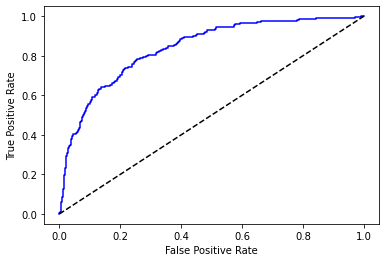

In [123]:
fpr, tpr, thresholds = roc_curve(Y, log.predict_proba(X)[:,1])

auc = roc_auc_score(Y, y_pred)


import matplotlib.pyplot as plt

plt.plot(fpr, tpr, color='blue', label = "Log Reg model (area = %0.2f)" %auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()